   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   -- ------------------------------------- 1.0/16.4 MB 13.8 MB/s eta 0:00:02
   ---------------------------------------- 16.4/16.4 MB 71.7 MB/s  0:00:00
Solving MILP for Equal Allocation (+10 beds)...
Solving MILP for Proportional Allocation (+10 beds)...
Solving MILP for Targeted Allocation (+10 beds)...

Running Monte Carlo Simulation (5000 Nights)...

🏆 THE 10-BED ALLOCATION SHOWDOWN SCORECARD
                                   Welfare  Turnaways  Transferred  \
Policy                                                               
3. Targeted Hubs (+10)           111321.60       1.71         6.93   
1. Equal Expansion (+10)         110693.80       1.97         6.84   
2. Proportional Expansion (+10)  110682.27       1.97         6.92   

                                 Total_Staff  
Policy                                        
3. Targeted Hubs (+10)                  19.0  
1. Equal Expansion (+10)             

C:\Users\Fangyuan Bao\AppData\Local\Temp\ipykernel_39888\2417719765.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


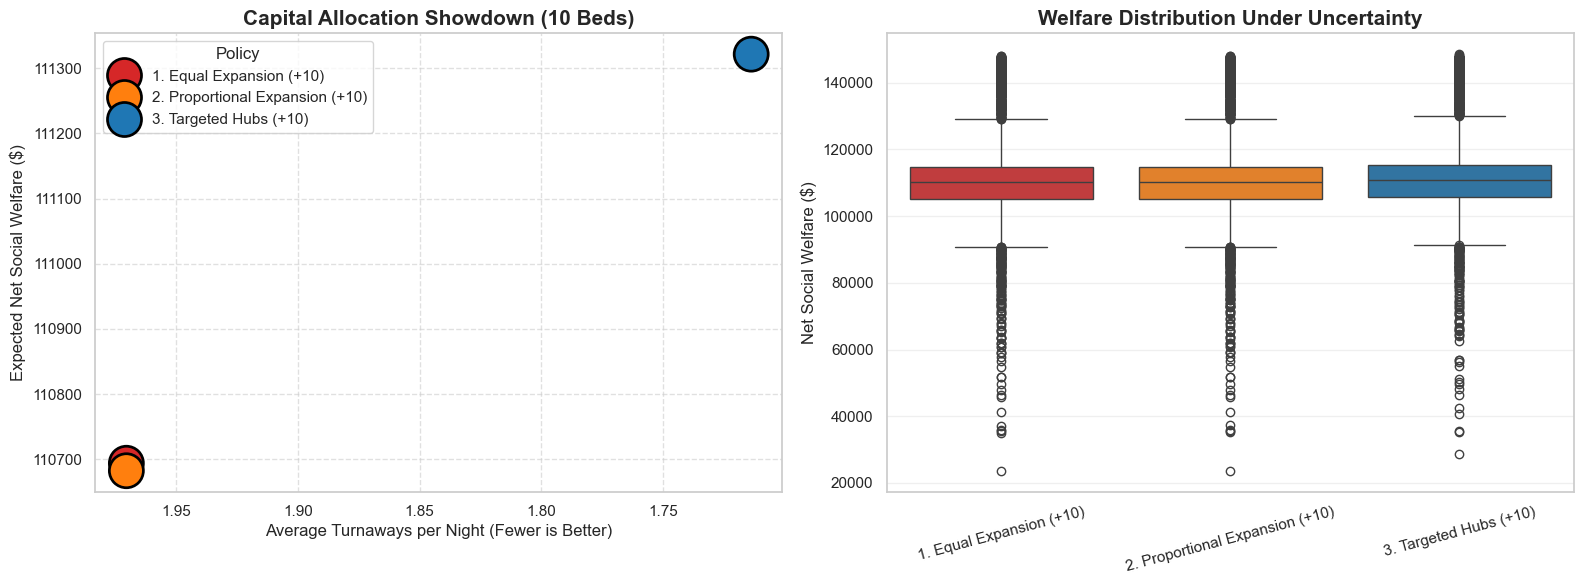

In [2]:
!pip install pulp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp


sns.set_theme(style="whitegrid")

ITERATIONS = 5000
HOURS_OPEN = 12
EXTREME_PROB = 0.12
STAFF_RATIO = 20
BENEFIT_PER_ADMIT = 500
PENALTY_PER_TURNAWAY = 2000
STAFF_COST_PER_UNIT = 312
TRANSFER_COST = 147

BASE_RATES = {"Elizabeth": 6.08, "George": 2.50, "Scarborough": 5.52, "NorthYork": 3.63, "Spadina": 1.76, "Cecil": 2.21, "Jimmie": 2.20}
EXTREME_ONLY_CENTERS = ["Cecil", "Jimmie"]

# Baseline
CAPS_ORIGINAL = {"Elizabeth": 75, "George": 30, "Scarborough": 68, "NorthYork": 46, "Spadina": 22, "Cecil": 30, "Jimmie": 30}



# Plan A: Equal (Equally distributed，First Three+2，Others+1)
CAPS_EQUAL = {
    "Elizabeth": 77, "Scarborough": 70, "NorthYork": 48,
    "George": 31, "Spadina": 23, "Cecil": 31, "Jimmie": 31
}

# Plan B: Proportional
CAPS_PROP = {
    "Elizabeth": 78, "Scarborough": 70, "NorthYork": 48,
    "George": 31, "Cecil": 31, "Jimmie": 31, "Spadina": 22
}

# Plan C: Targeted (Elizabeth +5, Scarborough +5)
CAPS_TARGET = {
    "Elizabeth": 80, "Scarborough": 73,
    "George": 30, "NorthYork": 46, "Spadina": 22, "Cecil": 30, "Jimmie": 30
}


def solve_stochastic_milp_custom(caps, num_scenarios=500):
    np.random.seed(99)
    scenarios = range(num_scenarios)
    demand_data = {c: {} for c in BASE_RATES}

    for s in scenarios:
        is_extreme = np.random.random() < EXTREME_PROB
        for c, rate in BASE_RATES.items():
            if (not is_extreme) and (c in EXTREME_ONLY_CENTERS):
                demand_data[c][s] = 0
                continue
            weather_mult = 1.0 if (is_extreme and c in EXTREME_ONLY_CENTERS) else (1.1 if is_extreme else 1.0)
            demand_data[c][s] = np.random.poisson(rate * HOURS_OPEN * weather_mult)

    model = pulp.LpProblem("Cap_Expansion", pulp.LpMaximize)
    staff_vars = pulp.LpVariable.dicts("Staff", BASE_RATES.keys(), lowBound=0, cat=pulp.LpInteger)
    served_vars = pulp.LpVariable.dicts("Served", [(c, s) for c in BASE_RATES.keys() for s in scenarios], lowBound=0, cat=pulp.LpInteger)
    local_vars = pulp.LpVariable.dicts("Local", [(c, s) for c in BASE_RATES.keys() for s in scenarios], lowBound=0, cat=pulp.LpInteger)
    turnaway_vars = pulp.LpVariable.dicts("Turnaway", scenarios, lowBound=0, cat=pulp.LpInteger)
    transfer_vars = pulp.LpVariable.dicts("Transfer", scenarios, lowBound=0, cat=pulp.LpInteger)

    expected_welfare = pulp.lpSum([(1.0/num_scenarios) * (BENEFIT_PER_ADMIT * pulp.lpSum([served_vars[(c, s)] for c in BASE_RATES.keys()]) - PENALTY_PER_TURNAWAY * turnaway_vars[s] - TRANSFER_COST * transfer_vars[s]) for s in scenarios])
    total_staff_cost = pulp.lpSum([STAFF_COST_PER_UNIT * staff_vars[c] for c in BASE_RATES.keys()])
    model += expected_welfare - total_staff_cost

    for s in scenarios:
        model += turnaway_vars[s] == sum(demand_data[c][s] for c in BASE_RATES.keys()) - pulp.lpSum([served_vars[(c, s)] for c in BASE_RATES.keys()])
        model += transfer_vars[s] == pulp.lpSum([served_vars[(c, s)] for c in BASE_RATES.keys()]) - pulp.lpSum([local_vars[(c, s)] for c in BASE_RATES.keys()])
        for c in BASE_RATES.keys():
            model += served_vars[(c, s)] <= caps[c]
            model += served_vars[(c, s)] <= STAFF_RATIO * staff_vars[c]
            model += local_vars[(c, s)] <= demand_data[c][s]
            model += local_vars[(c, s)] <= served_vars[(c, s)]
            model += staff_vars[c] <= np.ceil(caps[c] / STAFF_RATIO)

    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=60)
    model.solve(solver)
    return {c: int(staff_vars[c].varValue) for c in BASE_RATES.keys()}

print("Solving MILP for Equal Allocation (+10 beds)...")
STAFF_EQUAL = solve_stochastic_milp_custom(CAPS_EQUAL)

print("Solving MILP for Proportional Allocation (+10 beds)...")
STAFF_PROP = solve_stochastic_milp_custom(CAPS_PROP)

print("Solving MILP for Targeted Allocation (+10 beds)...")
STAFF_TARGET = solve_stochastic_milp_custom(CAPS_TARGET)

POLICIES = {
    "1. Equal Expansion (+10)": (CAPS_EQUAL, STAFF_EQUAL),
    "2. Proportional Expansion (+10)": (CAPS_PROP, STAFF_PROP),
    "3. Targeted Hubs (+10)": (CAPS_TARGET, STAFF_TARGET)
}


print("\nRunning Monte Carlo Simulation (5000 Nights)...")
all_results = []

for policy_name, (caps, staff_config) in POLICIES.items():
    np.random.seed(42)

    for i in range(ITERATIONS):
        is_extreme = np.random.random() < EXTREME_PROB
        total_demand = 0; total_initial_served = 0; total_overflow = 0; total_vacancy = 0; nightly_staff_cost = 0

        for center, base_rate in BASE_RATES.items():
            if (not is_extreme) and (center in EXTREME_ONLY_CENTERS): continue
            weather_mult = 1.0 if (is_extreme and center in EXTREME_ONLY_CENTERS) else (1.1 if is_extreme else 1.0)
            demand = np.random.poisson(base_rate * HOURS_OPEN * weather_mult)

            effective_cap = min(caps[center], staff_config[center] * STAFF_RATIO)

            total_demand += demand
            nightly_staff_cost += staff_config[center] * STAFF_COST_PER_UNIT

            if demand > effective_cap:
                total_overflow += (demand - effective_cap)
                total_initial_served += effective_cap
            else:
                total_vacancy += (effective_cap - demand)
                total_initial_served += demand

        transferred = min(total_overflow, total_vacancy)
        final_served = total_initial_served + transferred
        final_turnaway = total_overflow - transferred
        welfare = (final_served * BENEFIT_PER_ADMIT - final_turnaway * PENALTY_PER_TURNAWAY - transferred * TRANSFER_COST - nightly_staff_cost)

        all_results.append({
            "Policy": policy_name,
            "Turnaways": final_turnaway,
            "Transferred": transferred,
            "Welfare": welfare,
            "Total_Staff": sum(staff_config.values())
        })

df_all = pd.DataFrame(all_results)
scorecard = df_all.groupby("Policy")[["Welfare", "Turnaways", "Transferred", "Total_Staff"]].mean().round(2).sort_values("Welfare", ascending=False)

print("\n" + "="*50)
print("🏆 THE 10-BED ALLOCATION SHOWDOWN SCORECARD")
print("="*50)
print(scorecard)



print("\nGenerating final visualization...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
custom_palette = ["#d62728", "#ff7f0e", "#1f77b4"] # Red for Equal, Orange for Prop, Blue for Targeted

# Plot 1: Strategy Mapping (Scatter)
scatter_df = df_all.groupby("Policy")[["Turnaways", "Welfare"]].mean().reset_index()
sns.scatterplot(
    data=scatter_df, x="Turnaways", y="Welfare", hue="Policy",
    s=600, ax=axes[0], palette=custom_palette, edgecolor="black"
)
axes[0].invert_xaxis()
axes[0].set_title("Capital Allocation Showdown (10 Beds)", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Average Turnaways per Night (Fewer is Better)", fontsize=12)
axes[0].set_ylabel("Expected Net Social Welfare ($)", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.6)


# Plot 2: Welfare Boxplot
sns.boxplot(
    data=df_all, x="Policy", y="Welfare", ax=axes[1],
    palette=custom_palette
)
axes[1].set_title("Welfare Distribution Under Uncertainty", fontsize=15, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Net Social Welfare ($)", fontsize=12)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

✅ Safety Buffer (Original) Staffing: {'Elizabeth': 4, 'George': 2, 'Scarborough': 4, 'NorthYork': 3, 'Spadina': 2, 'Cecil': 2, 'Jimmie': 2} | Total: 19
Solving Targeted MILP Optimal (Expanded Capacity)...
✅ MILP Optimal (+10 Beds) Staffing: {'Elizabeth': 4, 'George': 2, 'Scarborough': 4, 'NorthYork': 3, 'Spadina': 2, 'Cecil': 2, 'Jimmie': 2} | Total: 19

🚀 Running Monte Carlo Simulation (5000 iterations)...

=== FINAL STRATEGIC SCORECARD ===
                                    Welfare  Turnaways  Transferred  \
Policy                                                                
MILP Optimal (Expanded +10 Beds)  111425.58       1.66         6.86   
Safety Buffer (Original Caps)     104623.96       4.35         7.65   

                                  Total_Staff  
Policy                                         
MILP Optimal (Expanded +10 Beds)         19.0  
Safety Buffer (Original Caps)            19.0  


C:\Users\Fangyuan Bao\AppData\Local\Temp\ipykernel_39888\2369761601.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


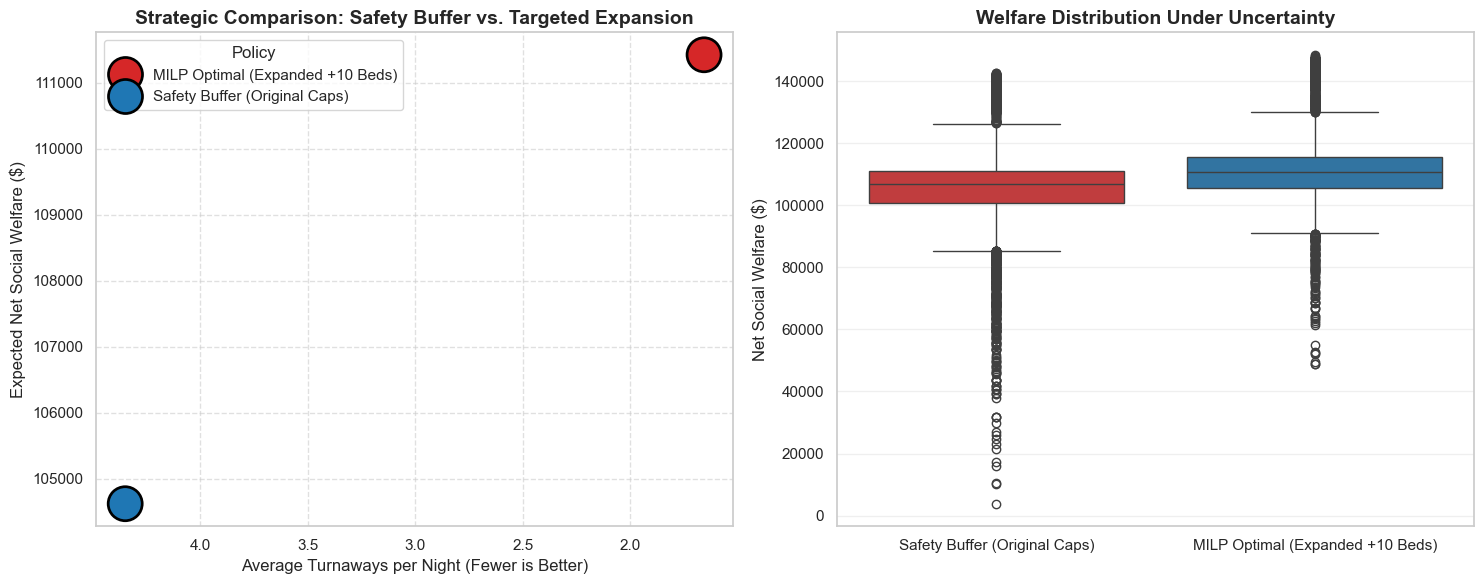

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

sns.set_theme(style="whitegrid")
np.random.seed(42)


ITERATIONS = 5000
HOURS_OPEN = 12
EXTREME_PROB = 0.12
STAFF_RATIO = 20  # 1 staff can support 20 clients/beds

BASE_RATES = {
    "Elizabeth": 6.08, "George": 2.50, "Scarborough": 5.52,
    "NorthYork": 3.63, "Spadina": 1.76, "Cecil": 2.21, "Jimmie": 2.20,
}

# [Original Capacity] Used by the Original Safety Buffer policy
CAPS_ORIGINAL = {
    "Elizabeth": 75, "George": 30, "Scarborough": 68,
    "NorthYork": 46, "Spadina": 22, "Cecil": 30, "Jimmie": 30,
}

# [Targeted Expanded Capacity] Used by MILP Optimal (Elizabeth +5, Scarborough +5)
CAPS_EXPANDED = {
    "Elizabeth": 80, "George": 30, "Scarborough": 73,
    "NorthYork": 46, "Spadina": 22, "Cecil": 30, "Jimmie": 30,
}

EXTREME_ONLY_CENTERS = ["Cecil", "Jimmie"]

BENEFIT_PER_ADMIT = 500
PENALTY_PER_TURNAWAY = 2000
STAFF_COST_PER_UNIT = 312
TRANSFER_COST = 147


# --- Policy 1: Original Safety Buffer (Based on Original Caps) ---
SAFETY_BUFFER = {}
for center, rate in BASE_RATES.items():
    peak_demand_est = (rate * HOURS_OPEN * 1.4) + 5
    safe_peak = min(CAPS_ORIGINAL[center], peak_demand_est)
    SAFETY_BUFFER[center] = int(np.ceil(safe_peak / STAFF_RATIO))

print(f"✅ Safety Buffer (Original) Staffing: {SAFETY_BUFFER} | Total: {sum(SAFETY_BUFFER.values())}")

# --- Policy 2: Targeted MILP Optimal (Based on Expanded Caps & Transfer Mechanism) ---
def solve_stochastic_milp_expanded(num_scenarios=500):
    print("Solving Targeted MILP Optimal (Expanded Capacity)...")
    np.random.seed(99)
    scenarios = range(num_scenarios)
    demand_data = {c: {} for c in BASE_RATES}

    # Generate Training Scenarios
    for s in scenarios:
        is_extreme = np.random.random() < EXTREME_PROB
        for center, base_rate in BASE_RATES.items():
            if (not is_extreme) and (center in EXTREME_ONLY_CENTERS):
                demand_data[center][s] = 0
                continue
            weather_mult = 1.0 if (is_extreme and center in EXTREME_ONLY_CENTERS) else (1.1 if is_extreme else 1.0)
            lam = base_rate * HOURS_OPEN * weather_mult
            demand_data[center][s] = np.random.poisson(lam)

    model = pulp.LpProblem("Targeted_Optimization", pulp.LpMaximize)

    # Decision Variables
    staff_vars = pulp.LpVariable.dicts("Staff", BASE_RATES.keys(), lowBound=0, cat=pulp.LpInteger)
    served_vars = pulp.LpVariable.dicts("Served", [(c, s) for c in BASE_RATES.keys() for s in scenarios], lowBound=0, cat=pulp.LpInteger)
    local_vars = pulp.LpVariable.dicts("Local", [(c, s) for c in BASE_RATES.keys() for s in scenarios], lowBound=0, cat=pulp.LpInteger)
    turnaway_vars = pulp.LpVariable.dicts("Turnaway", scenarios, lowBound=0, cat=pulp.LpInteger)
    transfer_vars = pulp.LpVariable.dicts("Transfer", scenarios, lowBound=0, cat=pulp.LpInteger)

    # Objective Function: Maximize Expected Net Social Welfare
    prob_s = 1.0 / num_scenarios
    expected_welfare = pulp.lpSum([
        prob_s * (
            BENEFIT_PER_ADMIT * pulp.lpSum([served_vars[(c, s)] for c in BASE_RATES.keys()])
            - PENALTY_PER_TURNAWAY * turnaway_vars[s]
            - TRANSFER_COST * transfer_vars[s]
        ) for s in scenarios
    ])
    total_staff_cost = pulp.lpSum([STAFF_COST_PER_UNIT * staff_vars[c] for c in BASE_RATES.keys()])

    model += expected_welfare - total_staff_cost, "Objective"

    # Constraints
    for s in scenarios:
        total_demand_s = sum(demand_data[c][s] for c in BASE_RATES.keys())
        total_served_s = pulp.lpSum([served_vars[(c, s)] for c in BASE_RATES.keys()])
        total_local_s = pulp.lpSum([local_vars[(c, s)] for c in BASE_RATES.keys()])

        model += turnaway_vars[s] == total_demand_s - total_served_s
        model += transfer_vars[s] == total_served_s - total_local_s

        for c in BASE_RATES.keys():
            # [Core logic] Applying the Expanded CAPS in the optimization constraints
            model += served_vars[(c, s)] <= CAPS_EXPANDED[c]
            model += served_vars[(c, s)] <= STAFF_RATIO * staff_vars[c]
            model += local_vars[(c, s)] <= demand_data[c][s]
            model += local_vars[(c, s)] <= served_vars[(c, s)]
            model += staff_vars[c] <= np.ceil(CAPS_EXPANDED[c] / STAFF_RATIO)

    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=60)
    model.solve(solver)

    if pulp.LpStatus[model.status] == 'Optimal':
        optimal_staffing = {c: int(staff_vars[c].varValue) for c in BASE_RATES.keys()}
        print(f"✅ MILP Optimal (+10 Beds) Staffing: {optimal_staffing} | Total: {sum(optimal_staffing.values())}")
        return optimal_staffing
    return {c: 3 for c in BASE_RATES.keys()}

MILP_EXPANDED = solve_stochastic_milp_expanded(num_scenarios=500)

POLICIES = {
    "Safety Buffer (Original Caps)": SAFETY_BUFFER,
    "MILP Optimal (Expanded +10 Beds)": MILP_EXPANDED
}


print("\n🚀 Running Monte Carlo Simulation (5000 iterations)...")
np.random.seed(42)
all_results = []

for policy_name, policy_config in POLICIES.items():
    # Dynamically select the applicable physical bed capacity limit for the current policy
    current_caps = CAPS_ORIGINAL if "Original Caps" in policy_name else CAPS_EXPANDED

    for i in range(ITERATIONS):
        is_extreme = np.random.random() < EXTREME_PROB
        scenario = "Extreme (-15°C)" if is_extreme else "Moderate (-5°C)"

        total_demand = 0; total_initial_served = 0; total_overflow = 0; total_vacancy = 0; nightly_staff_cost = 0

        for center, base_rate in BASE_RATES.items():
            if (not is_extreme) and (center in EXTREME_ONLY_CENTERS):
                continue

            weather_mult = 1.0 if (is_extreme and center in EXTREME_ONLY_CENTERS) else (1.1 if is_extreme else 1.0)
            demand = np.random.poisson(base_rate * HOURS_OPEN * weather_mult)

            # Apply the specific capacity based on the policy being simulated
            effective_cap = min(current_caps[center], policy_config[center] * STAFF_RATIO)

            total_demand += demand
            nightly_staff_cost += policy_config[center] * STAFF_COST_PER_UNIT

            if demand > effective_cap:
                total_overflow += (demand - effective_cap)
                total_initial_served += effective_cap
            else:
                total_vacancy += (effective_cap - demand)
                total_initial_served += demand

        transferred = min(total_overflow, total_vacancy)
        final_served = total_initial_served + transferred
        final_turnaway = total_overflow - transferred

        welfare = (
            final_served * BENEFIT_PER_ADMIT
            - final_turnaway * PENALTY_PER_TURNAWAY
            - transferred * TRANSFER_COST
            - nightly_staff_cost
        )

        all_results.append({
            "Policy": policy_name,
            "Scenario": scenario,
            "Turnaways": final_turnaway,
            "Transferred": transferred,
            "Welfare": welfare,
            "Total_Staff": sum(policy_config.values())
        })

df_all = pd.DataFrame(all_results)


scorecard = (
    df_all.groupby("Policy")[["Welfare", "Turnaways", "Transferred", "Total_Staff"]]
    .mean()
    .round(2)
    .sort_values("Welfare", ascending=False)
)

print("\n=== FINAL STRATEGIC SCORECARD ===")
print(scorecard)

# Generate Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Strategy Mapping
scatter_df = df_all.groupby("Policy")[["Turnaways", "Welfare"]].mean().reset_index()
sns.scatterplot(
    data=scatter_df, x="Turnaways", y="Welfare", hue="Policy",
    s=600, ax=axes[0], palette=["#d62728", "#1f77b4"], edgecolor="black"
)
axes[0].invert_xaxis()
axes[0].set_title("Strategic Comparison: Safety Buffer vs. Targeted Expansion", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Average Turnaways per Night (Fewer is Better)")
axes[0].set_ylabel("Expected Net Social Welfare ($)")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: Welfare Boxplot
sns.boxplot(
    data=df_all, x="Policy", y="Welfare", ax=axes[1],
    palette=["#d62728", "#1f77b4"]
)
axes[1].set_title("Welfare Distribution Under Uncertainty", fontsize=14, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Net Social Welfare ($)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()